In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation as mad
import pandas as pd
plt.style.use('thesis')

## Final 3-label plots
These have been generated using label bounds and a sum-prior

## Testing 3 6 and 10 labels with updated model
Log-fluxes vs linear fluxes

In [26]:
lin_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/linear-flux/snr1000_all_pred.npy')
lin_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/linear-flux/snr1000_all_true.npy')
log_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_pred.npy')
log_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_true.npy')

res_lin_6 = lin_pred_6 - lin_true_6
res_log_6 = log_pred_6 - log_true_6

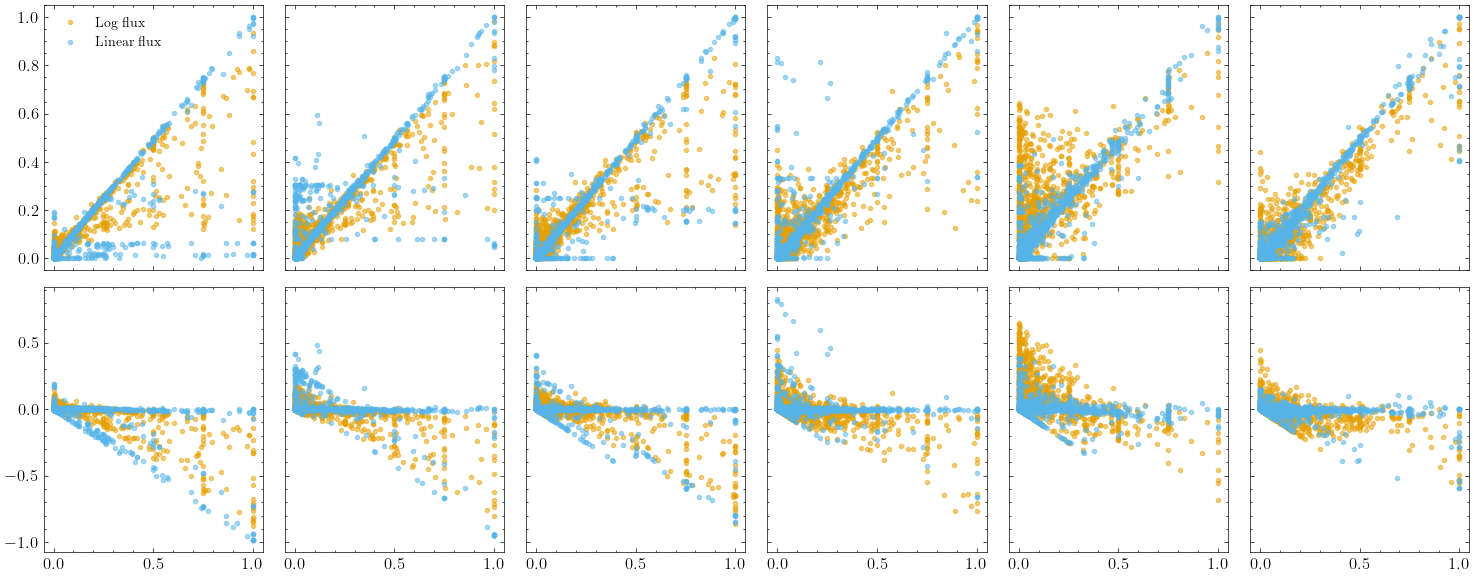

In [29]:
fig, ax = plt.subplots(2, 6, figsize=(15,6), sharex=True, sharey='row')
for i in range(6):
    ax[0, i].plot(log_true_6[:,i], log_pred_6[:,i], '.', alpha=0.5)
    ax[0, i].plot(lin_true_6[:,i], lin_pred_6[:,i], '.', alpha=0.5)
    ax[1, i].plot(log_true_6[:,i], res_log_6[:,i], '.', alpha=0.5)
    ax[1, i].plot(lin_true_6[:,i], res_lin_6[:,i], '.', alpha=0.5)
ax[0, 0].legend(['Log flux', 'Linear flux'], loc='upper left', fontsize=10)


plt.tight_layout()
plt.show()

In [47]:
print(f"MAD for log-models: {mad(res_log_6, axis=0)}")
print(f"Percentage of points outside 3MAD: {((np.abs(res_log_6) > 3*mad(res_log_6, axis=0)).sum(axis=0) / res_log_6.shape[0]) * 100}")
print(f"MAD for linear-models: {mad(res_lin_6, axis=0)}")
print(f"Percentage of points outside 3MAD: {((np.abs(res_lin_6) > 3*mad(res_lin_6, axis=0)).sum(axis=0) / res_lin_6.shape[0]) * 100}")

MAD for log-models: [0.00708806 0.02050051 0.02514824 0.04183479 0.09260386 0.03784822]
Percentage of points outside 3MAD: [31.7 24.5 16.3 15.6 16.7 18.3]
MAD for linear-models: [0.0027306  0.00440013 0.00394621 0.00673294 0.01619579 0.01225428]
Percentage of points outside 3MAD: [26.1 23.7 23.1 22.  20.6 19.5]
